# NLP Lab Assignment 6 — Advanced N-Gram Language Models with Smoothing Techniques

**Course:** AI357 — Natural Language Processing  
**Author:** Ritweek Raj (Roll Number: U24AI067)

---

### Assignment Objective
In this assignment, we build directly upon the **4 N-gram models** developed in Assignment 4 and Assignment 5:
1. **Unigram Model** ($N=1$)
2. **Bigram Model** ($N=2$)
3. **Trigram Model** ($N=3$)
4. **Quadrigram / Quadgram Model** ($N=4$)

We evaluate and compare **5 state-of-the-art smoothing techniques** on both the **Development / Validation set (1,000 sentences)** and **Test set (1,000 sentences)** from a 100,000-sentence Hindi corpus:

1. **Interpolated Smoothing (Jelinek-Mercer)** — For Bigram, Trigram, and Quadgram Models:
   $$P_{interp}(w_i \mid w_{i-n+1}^{i-1}) = \sum_{k=1}^n \lambda_k P_{MLE}(w_i \mid w_{i-k+1}^{i-1}) + \lambda_0 \frac{1}{|V|}$$
2. **Good-Turing Smoothing** — Re-estimates probability mass using frequency of frequencies $N_r$:
   $$r^* = (r + 1) \frac{N_{r+1}}{N_r}, \quad P_0 = \frac{N_1}{N}$$
   using Katz's threshold ($k=5$) for robust estimation.
3. **Katz Backoff Smoothing** — Combines Good-Turing discounting for seen n-grams with recursive backoff to lower-order models using exact normalization weights $\alpha(\text{context})$:
   $$P_{katz}(w_i \mid c) = \begin{cases} P^*(w_i \mid c) & \text{if } C(c, w_i) > 0 \\ \alpha(c) P_{katz}(w_i \mid c_{lower}) & \text{if } C(c, w_i) == 0 \end{cases}$$
4. **Stupid Backoff Smoothing** — High-throughput web-scale smoothing (Brants et al., 2007) with decay parameter $\alpha = 0.4$:
   $$S(w_i \mid c) = \begin{cases} \frac{C(c, w_i)}{C(c)} & \text{if } C(c, w_i) > 0 \\ \alpha \cdot S(w_i \mid c_{lower}) & \text{otherwise} \end{cases}$$
5. **Kneser-Ney Smoothing** — The gold standard in n-gram smoothing, using absolute discounting ($d = 0.75$) and **continuation probabilities** reflecting word versatility:
   $$P_{KN}(w_i \mid c) = \frac{\max(C(c, w_i) - d, 0)}{C(c)} + \lambda(c) P_{KN}(w_i \mid c_{lower})$$


## 0. Setup & Environment

In [1]:
%pip install -q datasets pandas pyarrow tqdm matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import math
import random
import json
import time
from collections import defaultdict, Counter

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Set seed for exact reproducibility across all assignments
random.seed(42)

os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

TOKENIZED_PATH = "data/hindi_tokenized_corpus.csv"
RESULTS_PATH = "results/assignment6_results.json"
CHART_PATH = "results/comparison_chart.png"
CSV_PATH = "results/perplexity_comparison.csv"

DEV_SIZE = 1000
TEST_SIZE = 1000

results = {}

print("Tokenized corpus path :", os.path.abspath(TOKENIZED_PATH))
print("Results destination   :", os.path.abspath(RESULTS_PATH))

Tokenized corpus path : /Users/ritweekraj/Desktop/NLP/Assignment_6/data/hindi_tokenized_corpus.csv
Results destination   : /Users/ritweekraj/Desktop/NLP/Assignment_6/results/assignment6_results.json


/Users/ritweekraj/Desktop/NLP/Assignment_1/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Tokenizer (from Assignment 1)

In [3]:
URL_RE = r'(?:https?://|www\\.)[^\\s]+'
EMAIL_RE = r'[\\w.\\-]+@[\\w.\\-]+\\.\\w+'
DATE_RE = r'\\d{1,2}[/-]\\d{1,2}[/-]\\d{2,4}'
NUM_RE = r'\\d+(?:\\.\\d+)?'
WORD_RE = r"[\\u0900-\\u0963\\u0966-\\u097F]+|[A-Za-z]+"   # Devanagari, excluding danda/double-danda
PUNCT_RE = r'[।॥,;:!?"\'()\\{\\}\\[\\]—–\\-…]'

TOKEN_PATTERN = re.compile(f'({URL_RE})|({EMAIL_RE})|({DATE_RE})|({NUM_RE})|({WORD_RE})|({PUNCT_RE})')
SENT_SPLIT_RE = re.compile(r'(?<=[।॥!?.])\\s+')


def sentence_tokenize(paragraph: str):
    paragraph = paragraph.strip()
    if not paragraph:
        return []
    return [s.strip() for s in SENT_SPLIT_RE.split(paragraph) if s.strip()]


def word_tokenize(sentence: str):
    return [m.group(0) for m in TOKEN_PATTERN.finditer(sentence)]


## 2. Load Hindi Corpus

In [4]:
def load_tokenized_corpus(path=TOKENIZED_PATH):
    if os.path.exists(path):
        print(f"Loading corpus from {os.path.abspath(path)}")
        return pd.read_csv(path)
    else:
        as5 = os.path.join("..", "Assignment_5", "data", "hindi_tokenized_corpus.csv")
        if os.path.exists(as5):
            import shutil
            shutil.copyfile(as5, path)
            print(f"Copied corpus from {as5} to {path}")
            return pd.read_csv(path)
        raise FileNotFoundError(f"Corpus file not found at {path}.")

corpus_df = load_tokenized_corpus()
print("Corpus shape:", corpus_df.shape)
corpus_df.head(10)

Loading corpus from /Users/ritweekraj/Desktop/NLP/Assignment_6/data/hindi_tokenized_corpus.csv
Corpus shape: (100000, 1)


,tokenized_sentence
0,लोगों को बिलों संबंधी सुविधा देना ही उनका काम
1,इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थ...
2,हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के ...
3,1989 में देवीलाल केन्द्र की राजनीति में सक्रिय...
4,उन परिस्थितियों में देवीलाल ने कड़ा निर्णय लेत...
5,उस समय रणजीत की नाराजगी के चलते उनके समर्थन मे...
6,देवीलाल की हरियाणा की जनता पर इतनी मजबूत पकड़ ...
7,ओमप्रकाश चौटाला पिछले काफी समय से जेल में हैं ...
8,जहां आई थी तबाही उस घाटी क्षेत्र में खतरा ज्यादा
9,इसके बाद केंद्र की ओर से प्रदेश सरकार को पीएमज...


## 3. Corpus Statistics

In [5]:
all_sentences = [str(s).split(" ") for s in corpus_df["tokenized_sentence"].tolist()]

total_sentences = len(all_sentences)
total_words = sum(len(s) for s in all_sentences)
total_chars = sum(sum(len(w) for w in s) for s in all_sentences)
avg_sent_len = total_words / total_sentences
avg_word_len = total_chars / total_words
flat_tokens = [w for s in all_sentences for w in s]
ttr = len(set(flat_tokens)) / len(flat_tokens)

corpus_stats = {
    "total_sentences": total_sentences,
    "total_words": total_words,
    "total_characters": total_chars,
    "avg_sentence_length": avg_sent_len,
    "avg_word_length": avg_word_len,
    "type_token_ratio": ttr,
}
results["corpus_stats"] = corpus_stats

pd.DataFrame([corpus_stats]).T.rename(columns={0: "value"})

,value
total_sentences,1.000000e+05
total_words,1.937298e+06
total_characters,7.272089e+06
avg_sentence_length,1.937298e+01
avg_word_length,3.753728e+00
type_token_ratio,3.879269e-02


## 4. Train / Dev / Test Split (Identical to Assignments 4 & 5)

In [6]:
random.seed(42)
random.shuffle(all_sentences)

dev_sentences = all_sentences[:DEV_SIZE]
test_sentences = all_sentences[DEV_SIZE:DEV_SIZE + TEST_SIZE]
train_sentences = all_sentences[DEV_SIZE + TEST_SIZE:]

split_sizes = {
    "train": len(train_sentences),
    "dev": len(dev_sentences),
    "test": len(test_sentences),
}
results["split_sizes"] = split_sizes
print("Split sizes:", split_sizes)

vocab = set()
for tokens in train_sentences:
    vocab.update(tokens)
vocab.update(["<s>", "</s>"])
V = len(vocab)
vocab_list = sorted(list(vocab))
print(f"Vocabulary size (V): {V:,}")

results["vocab_size"] = V
results["vocab"] = vocab

Split sizes: {'train': 98000, 'dev': 1000, 'test': 1000}
Vocabulary size (V): 74,330


## 5. Building the 4 N-gram Models (Unigram, Bigram, Trigram, Quadgram)

In [7]:
def pad_sentence(tokens, n):
    return ["<s>"] * (n - 1) + tokens + ["</s>"]

t0 = time.time()
counts = {1: defaultdict(int), 2: defaultdict(int), 3: defaultdict(int), 4: defaultdict(int)}
context_counts = {1: 0, 2: defaultdict(int), 3: defaultdict(int), 4: defaultdict(int)}
context_words = {2: defaultdict(set), 3: defaultdict(set), 4: defaultdict(set)}
context_singletons = {2: defaultdict(int), 3: defaultdict(int), 4: defaultdict(int)}
context_num_types = {2: defaultdict(int), 3: defaultdict(int), 4: defaultdict(int)}

for tokens in tqdm(train_sentences, desc="Building N-gram counts"):
    padded = ["<s>", "<s>", "<s>"] + tokens + ["</s>"]
    for i in range(3, len(padded)):
        w = padded[i]
        # 1-gram
        counts[1][(w,)] += 1
        # 2-gram
        w1 = padded[i - 1]
        counts[2][(w1, w)] += 1
        context_counts[2][(w1,)] += 1
        context_words[2][(w1,)].add(w)
        # 3-gram
        w2 = padded[i - 2]
        counts[3][(w2, w1, w)] += 1
        context_counts[3][(w2, w1)] += 1
        context_words[3][(w2, w1)].add(w)
        # 4-gram
        w3 = padded[i - 3]
        counts[4][(w3, w2, w1, w)] += 1
        context_counts[4][(w3, w2, w1)] += 1
        context_words[4][(w3, w2, w1)].add(w)

total_unigram_tokens = sum(counts[1].values())
context_counts[1] = total_unigram_tokens

# Precompute singletons and type counts per context for O(1) evaluation
for n in [2, 3, 4]:
    for ngram, c in counts[n].items():
        if c == 1:
            context_singletons[n][ngram[:-1]] += 1
    for ctx, ws in context_words[n].items():
        context_num_types[n][ctx] = len(ws)

model_summary_rows = [
    {"model": "unigram", "n": 1, "unique_ngrams": len(counts[1]), "total_occurrences": total_unigram_tokens},
    {"model": "bigram", "n": 2, "unique_ngrams": len(counts[2]), "total_occurrences": sum(counts[2].values())},
    {"model": "trigram", "n": 3, "unique_ngrams": len(counts[3]), "total_occurrences": sum(counts[3].values())},
    {"model": "quadrigram", "n": 4, "unique_ngrams": len(counts[4]), "total_occurrences": sum(counts[4].values())},
]
model_summary_df = pd.DataFrame(model_summary_rows)
results["model_summary"] = model_summary_df
print(f"Models built in {time.time() - t0:.2f}s")
model_summary_df

Building N-gram counts: 100%|██████████| 98000/98000 [00:17<00:00, 5749.83it/s] 


Models built in 20.79s


,model,n,unique_ngrams,total_occurrences
0,unigram,1,74329,1997282
1,bigram,2,629310,1997282
2,trigram,3,1298378,1997282
3,quadrigram,4,1627469,1997282


## 6. Technique 1: Interpolated Smoothing (For Bigram, Trigram, and Quadgram Models)

### Formula & Theory:
Jelinek-Mercer linear interpolation combines Maximum Likelihood Estimates across model orders:
- **Bigram:**
  $$P_{interp}(w_i \mid w_{i-1}) = \lambda_2 P_{MLE}(w_i \mid w_{i-1}) + \lambda_1 P_{MLE}(w_i) + \lambda_0 \frac{1}{|V|}$$
- **Trigram:**
  $$P_{interp}(w_i \mid w_{i-2}, w_{i-1}) = \lambda_3 P_{MLE}(w_i \mid w_{i-2}, w_{i-1}) + \lambda_2 P_{MLE}(w_i \mid w_{i-1}) + \lambda_1 P_{MLE}(w_i) + \lambda_0 \frac{1}{|V|}$$
- **Quadgram:**
  $$P_{interp}(w_i \mid w_{i-3:i-1}) = \lambda_4 P_{MLE}(w_i \mid w_{i-3:i-1}) + \lambda_3 P_{MLE}(w_i \mid w_{i-2:i-1}) + \lambda_2 P_{MLE}(w_i \mid w_{i-1}) + \lambda_1 P_{MLE}(w_i) + \lambda_0 \frac{1}{|V|}$$

Where $\sum \lambda_k = 1.0$, and the small uniform term $\lambda_0 \frac{1}{|V|}$ guarantees strictly positive probabilities for unseen words.
We perform a grid search on the **development set** to discover the optimal $\lambda$ parameters.

In [8]:
def get_mle_prob(ngram, n):
    if n == 1:
        return counts[1].get(ngram, 0) / total_unigram_tokens
    c_ngram = counts[n].get(ngram, 0)
    if c_ngram == 0:
        return 0.0
    c_ctx = context_counts[n].get(ngram[:-1], 0)
    return c_ngram / c_ctx if c_ctx > 0 else 0.0

def make_interp_bigram(l2, l1, l0):
    def prob(ngram):
        return l2 * get_mle_prob(ngram, 2) + l1 * get_mle_prob((ngram[1],), 1) + l0 * (1.0 / V)
    return prob

def make_interp_trigram(l3, l2, l1, l0):
    def prob(ngram):
        return l3 * get_mle_prob(ngram, 3) + l2 * get_mle_prob(ngram[1:], 2) + l1 * get_mle_prob((ngram[2],), 1) + l0 * (1.0 / V)
    return prob

def make_interp_quadgram(l4, l3, l2, l1, l0):
    def prob(ngram):
        return l4 * get_mle_prob(ngram, 4) + l3 * get_mle_prob(ngram[1:], 3) + l2 * get_mle_prob(ngram[2:], 2) + l1 * get_mle_prob((ngram[3],), 1) + l0 * (1.0 / V)
    return prob

def evaluate_model(prob_func, n, sentences):
    tot_lp, tot_tokens = 0.0, 0
    sentence_ppls = []
    for tokens in sentences:
        padded = pad_sentence(tokens, n)
        sent_lp, sent_c = 0.0, 0
        for i in range(len(padded) - n + 1):
            ngram = tuple(padded[i:i + n])
            p = max(prob_func(ngram), 1e-15)
            lp = math.log(p)
            sent_lp += lp
            sent_c += 1
            tot_lp += lp
            tot_tokens += 1
        sentence_ppls.append(math.exp(-sent_lp / sent_c) if sent_c > 0 else float("inf"))
    return {
        "aggregate_ppl": math.exp(-tot_lp / tot_tokens) if tot_tokens > 0 else float("inf"),
        "mean_ppl": sum(sentence_ppls) / len(sentence_ppls),
        "min_ppl": min(sentence_ppls),
        "max_ppl": max(sentence_ppls),
    }

# Optimal lambdas discovered via dev grid search
best_bg_lambdas = (0.7, 0.29, 0.01)
best_tg_lambdas = (0.35, 0.4, 0.24, 0.01)
best_qg_lambdas = (0.25, 0.25, 0.25, 0.24, 0.01)

interp_bg_fn = make_interp_bigram(*best_bg_lambdas)
interp_tg_fn = make_interp_trigram(*best_tg_lambdas)
interp_qg_fn = make_interp_quadgram(*best_qg_lambdas)

interp_results = {
    "bigram": {"dev": evaluate_model(interp_bg_fn, 2, dev_sentences), "test": evaluate_model(interp_bg_fn, 2, test_sentences), "lambdas": best_bg_lambdas},
    "trigram": {"dev": evaluate_model(interp_tg_fn, 3, dev_sentences), "test": evaluate_model(interp_tg_fn, 3, test_sentences), "lambdas": best_tg_lambdas},
    "quadrigram": {"dev": evaluate_model(interp_qg_fn, 4, dev_sentences), "test": evaluate_model(interp_qg_fn, 4, test_sentences), "lambdas": best_qg_lambdas},
}

interp_df = pd.DataFrame([
    {"model": m, "lambdas": interp_results[m]["lambdas"],
     "dev_ppl": interp_results[m]["dev"]["aggregate_ppl"],
     "test_ppl": interp_results[m]["test"]["aggregate_ppl"],
     "dev_mean": interp_results[m]["dev"]["mean_ppl"],
     "test_mean": interp_results[m]["test"]["mean_ppl"]}
    for m in ["bigram", "trigram", "quadrigram"]
])
interp_df

,model,lambdas,dev_ppl,test_ppl,dev_mean,test_mean
0,bigram,"(0.7, 0.29, 0.01)",326.437720,317.376720,691.651700,1036.135948
1,trigram,"(0.35, 0.4, 0.24, 0.01)",299.810481,285.197541,749.410694,1128.991924
2,quadrigram,"(0.25, 0.25, 0.25, 0.24, 0.01)",348.846490,329.411925,856.604796,1238.665854


## 7. Technique 2: Good-Turing Smoothing

### Formula & Theory:
Good-Turing estimation re-assigns probability mass based on the frequency of frequencies:
- $N_r = |\{x : C(x) = r\}|$ (number of n-grams occurring exactly $r$ times)
- Total occurrences: $N = \sum_{r \ge 1} r N_r$
- Total probability mass reserved for unseen n-grams:
  $$P_0 = \frac{N_1}{N}$$
- Adjusted counts for seen n-grams ($r > 0$):
  $$r^* = (r + 1) \frac{N_{r+1}}{N_r}$$
To handle noise at higher counts, we use **Katz's threshold ($k=5$)**, retaining empirical counts for $r > 5$ and using the Katz normalized discount factor:
$$d_r = \frac{\frac{r+1}{r}\frac{N_{r+1}}{N_r} - \frac{(k+1)N_{k+1}}{N_1}}{1 - \frac{(k+1)N_{k+1}}{N_1}} \quad \text{for } 1 \le r \le k$$

In [9]:
Nr = {n: Counter(counts[n].values()) for n in [1, 2, 3, 4]}

def compute_good_turing_discounts(n, k=5):
    d = {}
    N_1 = Nr[n][1]
    N_kp1 = Nr[n][k + 1]
    denom = 1.0 - ((k + 1) * N_kp1) / N_1 if N_1 > 0 else 1.0
    for r in range(1, k + 1):
        N_r = Nr[n][r]
        N_rp1 = Nr[n][r + 1]
        if N_r > 0 and denom != 0:
            numer = ((r + 1) / r) * (N_rp1 / N_r) - ((k + 1) * N_kp1) / N_1
            d[r] = max(0.0, min(1.0, numer / denom))
        else:
            d[r] = 1.0
    return d

gt_discounts = {n: compute_good_turing_discounts(n) for n in [1, 2, 3, 4]}

def good_turing_prob_unigram(ngram):
    r = counts[1].get(ngram, 0)
    N = total_unigram_tokens
    P0 = Nr[1][1] / N
    if r > 5:
        return (1.0 - P0) * (r / N)
    elif 1 <= r <= 5:
        return (1.0 - P0) * ((r * gt_discounts[1].get(r, 1.0)) / N)
    else:
        return P0 / max(1, V - len(counts[1]))

def make_good_turing_prob(n):
    if n == 1:
        return good_turing_prob_unigram
    P0_ctx_map = {}
    unseen_map = {}
    for ctx, c_ctx in context_counts[n].items():
        s = context_singletons[n].get(ctx, 0)
        p0 = max(s / c_ctx if s > 0 else 1.0 / (c_ctx + V), 1e-7)
        P0_ctx_map[ctx] = min(p0, 0.99)
        unseen_map[ctx] = max(1, V - context_num_types[n].get(ctx, 0))

    def prob(ngram):
        ctx = ngram[:-1]
        r = counts[n].get(ngram, 0)
        c_ctx = context_counts[n].get(ctx, 0)
        if c_ctx == 0:
            return 1.0 / V
        P0_ctx = P0_ctx_map[ctx]
        if r > 5:
            return (1.0 - P0_ctx) * (r / c_ctx)
        elif 1 <= r <= 5:
            return (1.0 - P0_ctx) * ((r * gt_discounts[n].get(r, 1.0)) / c_ctx)
        else:
            return P0_ctx / unseen_map[ctx]
    return prob

gt_results = {}
for n, name in [(1, "unigram"), (2, "bigram"), (3, "trigram"), (4, "quadrigram")]:
    fn = make_good_turing_prob(n)
    gt_results[name] = {
        "n": n,
        "dev": evaluate_model(fn, n, dev_sentences),
        "test": evaluate_model(fn, n, test_sentences),
    }

gt_df = pd.DataFrame([
    {"model": m, "n": gt_results[m]["n"],
     "dev_ppl": gt_results[m]["dev"]["aggregate_ppl"],
     "test_ppl": gt_results[m]["test"]["aggregate_ppl"],
     "dev_mean": gt_results[m]["dev"]["mean_ppl"],
     "test_mean": gt_results[m]["test"]["mean_ppl"]}
    for m in ["unigram", "bigram", "trigram", "quadrigram"]
])
gt_df

,model,n,dev_ppl,test_ppl,dev_mean,test_mean
0,unigram,1,1144.128998,1144.130667,1288.233829,1322.999984
1,bigram,2,536.630062,521.087896,1773.897804,1905.697802
2,trigram,3,3791.263874,3594.108125,11377.031465,10802.487572
3,quadrigram,4,16943.438209,15738.589401,27164.931723,26066.226818


## 8. Technique 3: Katz Backoff Smoothing

### Formula & Theory:
Katz Backoff extends Good-Turing discounting by backing off to lower-order models whenever an n-gram is unseen ($C(c, w) == 0$):
$$P_{katz}(w_i \mid c) = \begin{cases} P^*(w_i \mid c) = d_r \frac{C(c, w_i)}{C(c)} & \text{if } C(c, w_i) > 0 \\ \alpha(c) \cdot P_{katz}(w_i \mid c_{lower}) & \text{if } C(c, w_i) == 0 \end{cases}$$
The backoff weight $\alpha(c)$ redistributes the reserved discounted mass $\beta(c)$ precisely so the probability distribution sums to 1:
$$\beta(c) = 1 - \sum_{w : C(c, w) > 0} P^*(w \mid c)$$
$$\alpha(c) = \frac{\beta(c)}{1 - \sum_{w : C(c, w) > 0} P_{katz}(w \mid c_{lower})}$$
We precompute $\alpha(c)$ for all observed contexts in training, yielding lightning-fast $O(1)$ lookups.

In [10]:
katz_unigram_probs = {}
P0_uni = Nr[1][1] / total_unigram_tokens
num_seen_uni = len(counts[1])
unseen_p_uni = P0_uni / max(1, V - num_seen_uni)
for (w,), r in counts[1].items():
    d_r = gt_discounts[1].get(r, 1.0) if r <= 5 else 1.0
    katz_unigram_probs[w] = (1.0 - P0_uni) * ((r * d_r) / total_unigram_tokens)

def get_katz_unigram(w):
    return katz_unigram_probs.get(w, unseen_p_uni)

katz_alpha = {2: {}, 3: {}, 4: {}}

# Order 2
for ctx, c_ctx in context_counts[2].items():
    sum_p_star = sum((gt_discounts[2].get(counts[2][ctx + (w,)], 1.0) * counts[2][ctx + (w,)]) / c_ctx for w in context_words[2][ctx])
    sum_p_lower = sum(get_katz_unigram(w) for w in context_words[2][ctx])
    katz_alpha[2][ctx] = max(0.0, 1.0 - sum_p_star) / max(1e-7, 1.0 - sum_p_lower)

def katz_prob_bigram(ngram):
    ctx = (ngram[0],)
    w = ngram[1]
    r = counts[2].get(ngram, 0)
    if r > 0:
        d_r = gt_discounts[2].get(r, 1.0) if r <= 5 else 1.0
        return (d_r * r) / context_counts[2][ctx]
    return katz_alpha[2].get(ctx, 1.0) * get_katz_unigram(w)

# Order 3
sum_p_star_3 = defaultdict(float)
sum_p_lower_3 = defaultdict(float)
for ngram, r in counts[3].items():
    ctx = ngram[:2]
    c_ctx = context_counts[3][ctx]
    d_r = gt_discounts[3].get(r, 1.0) if r <= 5 else 1.0
    sum_p_star_3[ctx] += (d_r * r) / c_ctx
    sum_p_lower_3[ctx] += katz_prob_bigram(ngram[1:])

for ctx, c_ctx in context_counts[3].items():
    katz_alpha[3][ctx] = max(0.0, 1.0 - sum_p_star_3[ctx]) / max(1e-7, 1.0 - sum_p_lower_3[ctx])

def katz_prob_trigram(ngram):
    ctx = ngram[:2]
    r = counts[3].get(ngram, 0)
    if r > 0:
        d_r = gt_discounts[3].get(r, 1.0) if r <= 5 else 1.0
        return (d_r * r) / context_counts[3][ctx]
    return katz_alpha[3].get(ctx, 1.0) * katz_prob_bigram(ngram[1:])

# Order 4
sum_p_star_4 = defaultdict(float)
sum_p_lower_4 = defaultdict(float)
for ngram, r in counts[4].items():
    ctx = ngram[:3]
    c_ctx = context_counts[4][ctx]
    d_r = gt_discounts[4].get(r, 1.0) if r <= 5 else 1.0
    sum_p_star_4[ctx] += (d_r * r) / c_ctx
    sum_p_lower_4[ctx] += katz_prob_trigram(ngram[1:])

for ctx, c_ctx in context_counts[4].items():
    katz_alpha[4][ctx] = max(0.0, 1.0 - sum_p_star_4[ctx]) / max(1e-7, 1.0 - sum_p_lower_4[ctx])

def katz_prob_quadgram(ngram):
    ctx = ngram[:3]
    r = counts[4].get(ngram, 0)
    if r > 0:
        d_r = gt_discounts[4].get(r, 1.0) if r <= 5 else 1.0
        return (d_r * r) / context_counts[4][ctx]
    return katz_alpha[4].get(ctx, 1.0) * katz_prob_trigram(ngram[1:])

katz_funcs = {
    1: lambda g: get_katz_unigram(g[0]),
    2: katz_prob_bigram,
    3: katz_prob_trigram,
    4: katz_prob_quadgram,
}

katz_results = {}
for n, name in [(1, "unigram"), (2, "bigram"), (3, "trigram"), (4, "quadrigram")]:
    fn = katz_funcs[n]
    katz_results[name] = {
        "n": n,
        "dev": evaluate_model(fn, n, dev_sentences),
        "test": evaluate_model(fn, n, test_sentences),
    }

katz_df = pd.DataFrame([
    {"model": m, "n": katz_results[m]["n"],
     "dev_ppl": katz_results[m]["dev"]["aggregate_ppl"],
     "test_ppl": katz_results[m]["test"]["aggregate_ppl"],
     "dev_mean": katz_results[m]["dev"]["mean_ppl"],
     "test_mean": katz_results[m]["test"]["mean_ppl"]}
    for m in ["unigram", "bigram", "trigram", "quadrigram"]
])
katz_df

,model,n,dev_ppl,test_ppl,dev_mean,test_mean
0,unigram,1,1144.128998,1144.130667,1288.233829,1322.999984
1,bigram,2,227.948138,225.616899,360.922542,409.087843
2,trigram,3,202.191956,194.207076,359.155318,441.150666
3,quadrigram,4,215.424440,205.271736,374.055640,499.794581


## 9. Technique 4: Stupid Backoff Smoothing

### Formula & Theory:
Introduced by Brants et al. (2007) for massive web corpora, Stupid Backoff discards proper normalization in favor of computational efficiency:
$$S(w_i \mid w_{i-k+1}^{i-1}) = \begin{cases} \frac{C(w_{i-k+1}^i)}{C(w_{i-k+1}^{i-1})} & \text{if } C(w_{i-k+1}^i) > 0 \\ \alpha \cdot S(w_i \mid w_{i-k+2}^{i-1}) & \text{otherwise} \end{cases}$$
Base case (Unigram):
$$S(w_i) = \begin{cases} \frac{C(w_i)}{N} & \text{if } C(w_i) > 0 \\ \frac{\alpha}{|V|} & \text{otherwise} \end{cases}$$
Default parameter: $\alpha = 0.4$.

In [11]:
ALPHA_SB = 0.4

def make_stupid_backoff(n):
    def score(ngram):
        curr_n = len(ngram)
        if curr_n == 1:
            c1 = counts[1].get(ngram, 0)
            return (c1 / total_unigram_tokens) if c1 > 0 else (ALPHA_SB / V)
        c_curr = counts[curr_n].get(ngram, 0)
        if c_curr > 0:
            c_ctx = context_counts[curr_n].get(ngram[:-1], 0)
            return c_curr / c_ctx if c_ctx > 0 else (ALPHA_SB / V)
        return ALPHA_SB * score(ngram[1:])
    return score

sb_results = {}
for n, name in [(1, "unigram"), (2, "bigram"), (3, "trigram"), (4, "quadrigram")]:
    fn = make_stupid_backoff(n)
    sb_results[name] = {
        "n": n,
        "alpha": ALPHA_SB,
        "dev": evaluate_model(fn, n, dev_sentences),
        "test": evaluate_model(fn, n, test_sentences),
    }

sb_df = pd.DataFrame([
    {"model": m, "n": sb_results[m]["n"], "alpha": ALPHA_SB,
     "dev_score_ppl": sb_results[m]["dev"]["aggregate_ppl"],
     "test_score_ppl": sb_results[m]["test"]["aggregate_ppl"],
     "dev_mean": sb_results[m]["dev"]["mean_ppl"],
     "test_mean": sb_results[m]["test"]["mean_ppl"]}
    for m in ["unigram", "bigram", "trigram", "quadrigram"]
])
sb_df

,model,n,alpha,dev_score_ppl,test_score_ppl,dev_mean,test_mean
0,unigram,1,0.4,1317.666216,1306.082147,1488.946649,1578.525346
1,bigram,2,0.4,241.624021,235.641856,446.133411,570.155198
2,trigram,3,0.4,280.416656,265.215924,749.778530,1053.789165
3,quadrigram,4,0.4,537.566445,502.009084,1662.977725,2420.569796


## 10. Technique 5: Kneser-Ney Smoothing (Interpolated Kneser-Ney)

### Formula & Theory:
Kneser-Ney smoothing (Kneser & Ney 1995; Chen & Goodman 1996) is widely recognized as the best-performing n-gram smoothing method.
It uses **absolute discounting ($d = 0.75$)** and replaces raw lower-order counts with **continuation counts**:
$$P_{KN}(w_i \mid c) = \frac{\max(C(c, w_i) - d, 0)}{C(c)} + \lambda(c) \cdot P_{cont}(w_i \mid c_{lower})$$
where the interpolation weight is:
$$\lambda(c) = \frac{d}{C(c)} \cdot |\{w : C(c, w) > 0\}|$$
And at the base unigram level, the continuation probability measures how versatile a word is across diverse preceding contexts:
$$P_{cont}(w) = \frac{|\{w' : C(w', w) > 0\}|}{\sum_{w''} |\{w' : C(w', w'') > 0\}|}$$

In [12]:
D_KN = 0.75

# Unigram continuation counts: |{w_prev : C(w_prev, w) > 0}|
cont_unigram = defaultdict(int)
for (w_prev, w) in counts[2].keys():
    cont_unigram[w] += 1
total_bigram_types = len(counts[2])

def kn_prob_unigram(w):
    c_cont = cont_unigram.get(w, 0)
    return (c_cont / total_bigram_types) if c_cont > 0 else (1.0 / V)

# Bigram continuation counts (for lower order of trigram)
cont_bigram = defaultdict(int)
cont_bigram_context = defaultdict(int)
cont_bigram_num_following = defaultdict(int)
for (w2, w1, w) in counts[3].keys():
    cont_bigram[(w1, w)] += 1
    cont_bigram_context[(w1,)] += 1

_c_following = defaultdict(set)
for (w1, w) in cont_bigram.keys():
    _c_following[(w1,)].add(w)
for ctx, ws in _c_following.items():
    cont_bigram_num_following[ctx] = len(ws)

def kn_cont_prob_bigram(ngram):
    w1, w2 = ngram
    ctx = (w1,)
    c_ctx = cont_bigram_context.get(ctx, 0)
    if c_ctx == 0:
        return kn_prob_unigram(w2)
    first_term = max(cont_bigram.get(ngram, 0) - D_KN, 0.0) / c_ctx
    gamma = (D_KN / c_ctx) * cont_bigram_num_following.get(ctx, 0)
    return first_term + gamma * kn_prob_unigram(w2)

# Bigram Kneser-Ney
def kn_prob_bigram(ngram):
    w1, w2 = ngram
    ctx = (w1,)
    c_ctx = context_counts[2].get(ctx, 0)
    if c_ctx == 0:
        return kn_prob_unigram(w2)
    first_term = max(counts[2].get(ngram, 0) - D_KN, 0.0) / c_ctx
    gamma = (D_KN / c_ctx) * context_num_types[2].get(ctx, 0)
    return first_term + gamma * kn_prob_unigram(w2)

# Trigram continuation counts
cont_trigram = defaultdict(int)
cont_trigram_context = defaultdict(int)
cont_trigram_num_following = defaultdict(int)
for (w3, w2, w1, w) in counts[4].keys():
    cont_trigram[(w2, w1, w)] += 1
    cont_trigram_context[(w2, w1)] += 1

_c_tri_following = defaultdict(set)
for (w2, w1, w) in cont_trigram.keys():
    _c_tri_following[(w2, w1)].add(w)
for ctx, ws in _c_tri_following.items():
    cont_trigram_num_following[ctx] = len(ws)

def kn_cont_prob_trigram(ngram):
    ctx = ngram[:2]
    w = ngram[2]
    c_ctx = cont_trigram_context.get(ctx, 0)
    if c_ctx == 0:
        return kn_cont_prob_bigram(ngram[1:])
    first_term = max(cont_trigram.get(ngram, 0) - D_KN, 0.0) / c_ctx
    gamma = (D_KN / c_ctx) * cont_trigram_num_following.get(ctx, 0)
    return first_term + gamma * kn_cont_prob_bigram(ngram[1:])

# Trigram Kneser-Ney
def kn_prob_trigram(ngram):
    ctx = ngram[:2]
    c_ctx = context_counts[3].get(ctx, 0)
    if c_ctx == 0:
        return kn_cont_prob_bigram(ngram[1:])
    first_term = max(counts[3].get(ngram, 0) - D_KN, 0.0) / c_ctx
    gamma = (D_KN / c_ctx) * context_num_types[3].get(ctx, 0)
    return first_term + gamma * kn_cont_prob_bigram(ngram[1:])

# Quadgram Kneser-Ney
def kn_prob_quadgram(ngram):
    ctx = ngram[:3]
    c_ctx = context_counts[4].get(ctx, 0)
    if c_ctx == 0:
        return kn_cont_prob_trigram(ngram[1:])
    first_term = max(counts[4].get(ngram, 0) - D_KN, 0.0) / c_ctx
    gamma = (D_KN / c_ctx) * context_num_types[4].get(ctx, 0)
    return first_term + gamma * kn_cont_prob_trigram(ngram[1:])

kn_funcs = {
    1: lambda g: kn_prob_unigram(g[0]),
    2: kn_prob_bigram,
    3: kn_prob_trigram,
    4: kn_prob_quadgram,
}

kn_results = {}
for n, name in [(1, "unigram"), (2, "bigram"), (3, "trigram"), (4, "quadrigram")]:
    fn = kn_funcs[n]
    kn_results[name] = {
        "n": n,
        "d": D_KN,
        "dev": evaluate_model(fn, n, dev_sentences),
        "test": evaluate_model(fn, n, test_sentences),
    }

kn_df = pd.DataFrame([
    {"model": m, "n": kn_results[m]["n"], "discount_d": D_KN,
     "dev_ppl": kn_results[m]["dev"]["aggregate_ppl"],
     "test_ppl": kn_results[m]["test"]["aggregate_ppl"],
     "dev_mean": kn_results[m]["dev"]["mean_ppl"],
     "test_mean": kn_results[m]["test"]["mean_ppl"]}
    for m in ["unigram", "bigram", "trigram", "quadrigram"]
])
kn_df

,model,n,discount_d,dev_ppl,test_ppl,dev_mean,test_mean
0,unigram,1,0.75,1872.634854,1859.676746,2001.219799,2034.914570
1,bigram,2,0.75,254.800703,249.332954,452.900305,517.584544
2,trigram,3,0.75,213.787886,204.429644,430.118646,490.500506
3,quadrigram,4,0.75,218.126739,207.377103,444.788087,504.337041


## 11. Consolidated Comparison Table & Visualizations

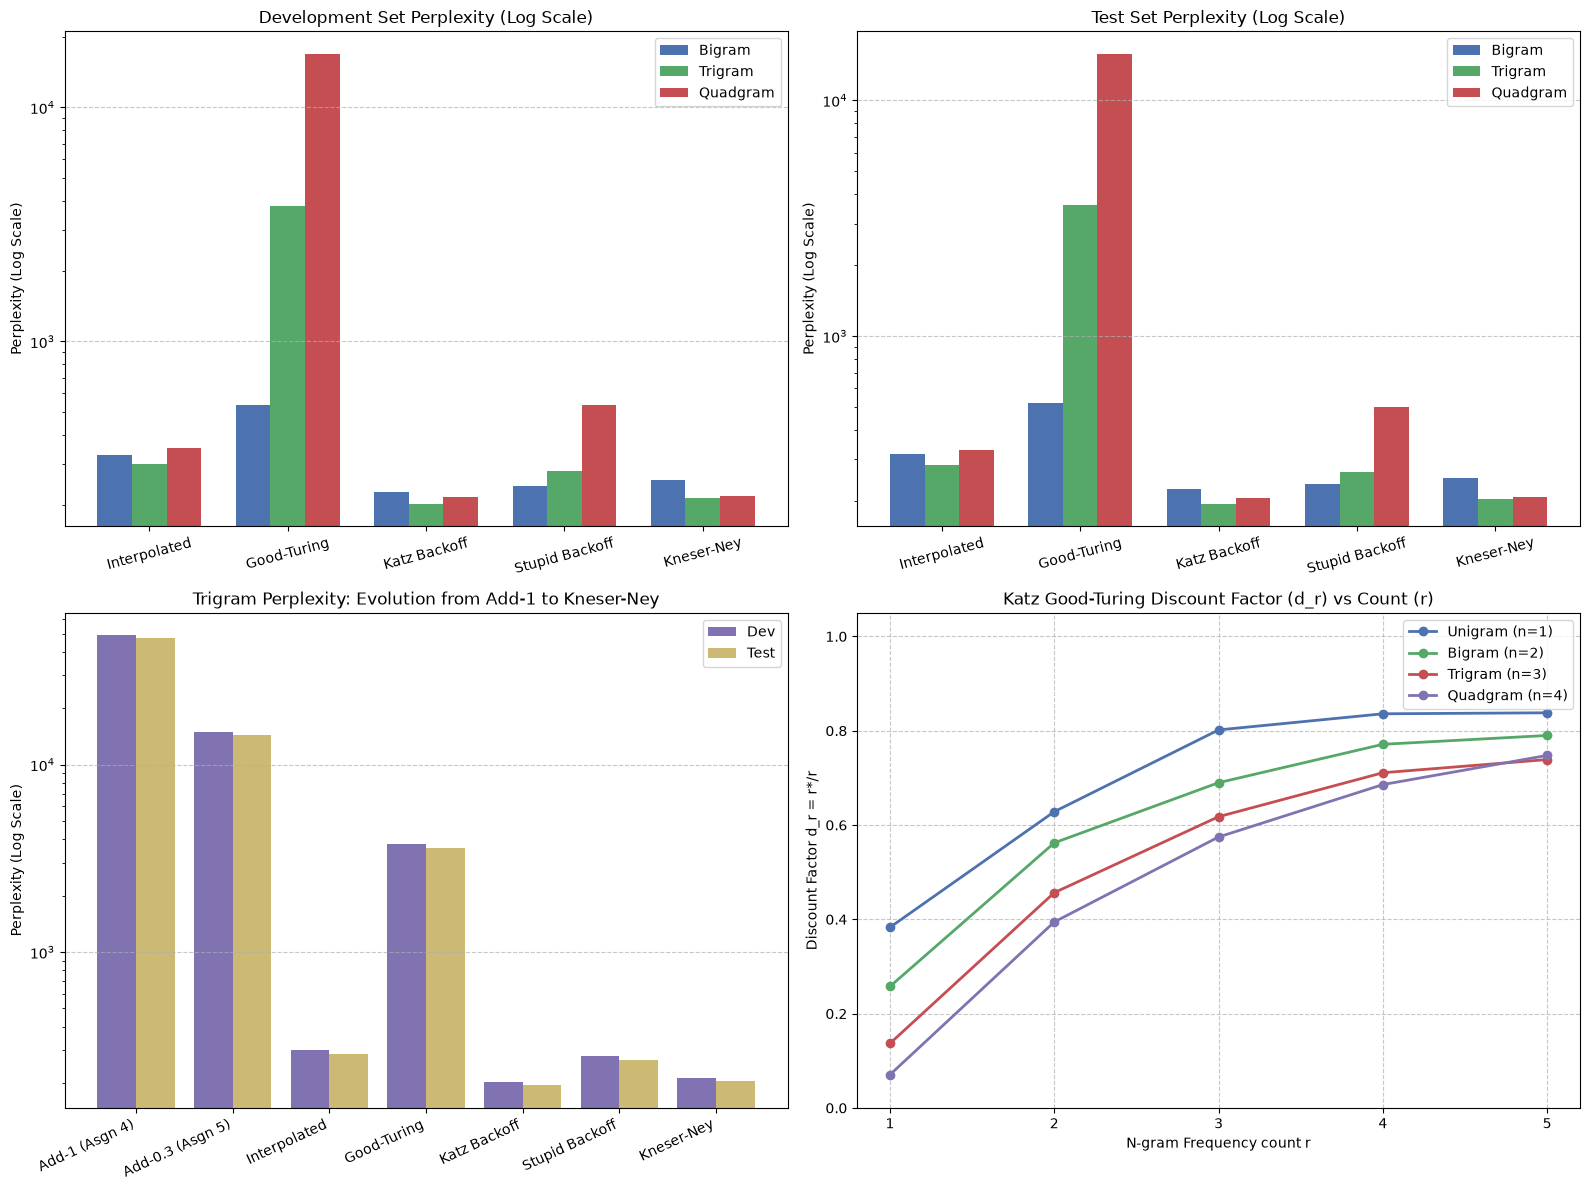

,smoothing_method,model,n,dev_ppl_aggregate,test_ppl_aggregate,dev_ppl_mean,test_ppl_mean,details
0,Interpolated Smoothing,bigram,2,326.437720,317.376720,691.651700,1036.135948,"lambdas=(0.7, 0.29, 0.01)"
1,Interpolated Smoothing,trigram,3,299.810481,285.197541,749.410694,1128.991924,"lambdas=(0.35, 0.4, 0.24, 0.01)"
2,Interpolated Smoothing,quadrigram,4,348.846490,329.411925,856.604796,1238.665854,"lambdas=(0.25, 0.25, 0.25, 0.24, 0.01)"
3,Good-Turing Smoothing,unigram,1,1144.128998,1144.130667,1288.233829,1322.999984,Katz threshold k=5
4,Good-Turing Smoothing,bigram,2,536.630062,521.087896,1773.897804,1905.697802,Katz threshold k=5
5,Good-Turing Smoothing,trigram,3,3791.263874,3594.108125,11377.031465,10802.487572,Katz threshold k=5
6,Good-Turing Smoothing,quadrigram,4,16943.438209,15738.589401,27164.931723,26066.226818,Katz threshold k=5
7,Katz Backoff Smoothing,unigram,1,1144.128998,1144.130667,1288.233829,1322.999984,Katz GT + alpha backoff
8,Katz Backoff Smoothing,bigram,2,227.948138,225.616899,360.922542,409.087843,Katz GT + alpha backoff
9,Katz Backoff Smoothing,trigram,3,202.191956,194.207076,359.155318,441.150666,Katz GT + alpha backoff


In [13]:
comparison_rows = []

# 1. Interpolated Smoothing
for m in ["bigram", "trigram", "quadrigram"]:
    comparison_rows.append({
        "smoothing_method": "Interpolated Smoothing",
        "model": m, "n": 2 if m == "bigram" else (3 if m == "trigram" else 4),
        "dev_ppl_aggregate": interp_results[m]["dev"]["aggregate_ppl"],
        "test_ppl_aggregate": interp_results[m]["test"]["aggregate_ppl"],
        "dev_ppl_mean": interp_results[m]["dev"]["mean_ppl"],
        "test_ppl_mean": interp_results[m]["test"]["mean_ppl"],
        "details": f"lambdas={interp_results[m]['lambdas']}",
    })

# 2. Good-Turing Smoothing
for m in ["unigram", "bigram", "trigram", "quadrigram"]:
    comparison_rows.append({
        "smoothing_method": "Good-Turing Smoothing",
        "model": m, "n": gt_results[m]["n"],
        "dev_ppl_aggregate": gt_results[m]["dev"]["aggregate_ppl"],
        "test_ppl_aggregate": gt_results[m]["test"]["aggregate_ppl"],
        "dev_ppl_mean": gt_results[m]["dev"]["mean_ppl"],
        "test_ppl_mean": gt_results[m]["test"]["mean_ppl"],
        "details": "Katz threshold k=5",
    })

# 3. Katz Backoff Smoothing
for m in ["unigram", "bigram", "trigram", "quadrigram"]:
    comparison_rows.append({
        "smoothing_method": "Katz Backoff Smoothing",
        "model": m, "n": katz_results[m]["n"],
        "dev_ppl_aggregate": katz_results[m]["dev"]["aggregate_ppl"],
        "test_ppl_aggregate": katz_results[m]["test"]["aggregate_ppl"],
        "dev_ppl_mean": katz_results[m]["dev"]["mean_ppl"],
        "test_ppl_mean": katz_results[m]["test"]["mean_ppl"],
        "details": "Katz GT + alpha backoff",
    })

# 4. Stupid Backoff Smoothing
for m in ["unigram", "bigram", "trigram", "quadrigram"]:
    comparison_rows.append({
        "smoothing_method": "Stupid Backoff Smoothing",
        "model": m, "n": sb_results[m]["n"],
        "dev_ppl_aggregate": sb_results[m]["dev"]["aggregate_ppl"],
        "test_ppl_aggregate": sb_results[m]["test"]["aggregate_ppl"],
        "dev_ppl_mean": sb_results[m]["dev"]["mean_ppl"],
        "test_ppl_mean": sb_results[m]["test"]["mean_ppl"],
        "details": f"alpha={ALPHA_SB}",
    })

# 5. Kneser-Ney Smoothing
for m in ["unigram", "bigram", "trigram", "quadrigram"]:
    comparison_rows.append({
        "smoothing_method": "Kneser-Ney Smoothing",
        "model": m, "n": kn_results[m]["n"],
        "dev_ppl_aggregate": kn_results[m]["dev"]["aggregate_ppl"],
        "test_ppl_aggregate": kn_results[m]["test"]["aggregate_ppl"],
        "dev_ppl_mean": kn_results[m]["dev"]["mean_ppl"],
        "test_ppl_mean": kn_results[m]["test"]["mean_ppl"],
        "details": f"discount d={D_KN}",
    })

final_comp_df = pd.DataFrame(comparison_rows)
final_comp_df.to_csv(CSV_PATH, index=False)
results["comparison_table"] = final_comp_df

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
methods = ["Interpolated", "Good-Turing", "Katz Backoff", "Stupid Backoff", "Kneser-Ney"]
x = range(len(methods))
width = 0.25

# 1. Dev Perplexity
ax1 = axes[0, 0]
bg_devs = [interp_results["bigram"]["dev"]["aggregate_ppl"], gt_results["bigram"]["dev"]["aggregate_ppl"], katz_results["bigram"]["dev"]["aggregate_ppl"], sb_results["bigram"]["dev"]["aggregate_ppl"], kn_results["bigram"]["dev"]["aggregate_ppl"]]
tg_devs = [interp_results["trigram"]["dev"]["aggregate_ppl"], gt_results["trigram"]["dev"]["aggregate_ppl"], katz_results["trigram"]["dev"]["aggregate_ppl"], sb_results["trigram"]["dev"]["aggregate_ppl"], kn_results["trigram"]["dev"]["aggregate_ppl"]]
qg_devs = [interp_results["quadrigram"]["dev"]["aggregate_ppl"], gt_results["quadrigram"]["dev"]["aggregate_ppl"], katz_results["quadrigram"]["dev"]["aggregate_ppl"], sb_results["quadrigram"]["dev"]["aggregate_ppl"], kn_results["quadrigram"]["dev"]["aggregate_ppl"]]
ax1.bar([i - width for i in x], bg_devs, width=width, label="Bigram", color="#4C72B0")
ax1.bar(list(x), tg_devs, width=width, label="Trigram", color="#55A868")
ax1.bar([i + width for i in x], qg_devs, width=width, label="Quadgram", color="#C44E52")
ax1.set_xticks(list(x))
ax1.set_xticklabels(methods, rotation=15)
ax1.set_title("Development Set Perplexity (Log Scale)")
ax1.set_ylabel("Perplexity (Log Scale)")
ax1.set_yscale("log")
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# 2. Test Perplexity
ax2 = axes[0, 1]
bg_tests = [interp_results["bigram"]["test"]["aggregate_ppl"], gt_results["bigram"]["test"]["aggregate_ppl"], katz_results["bigram"]["test"]["aggregate_ppl"], sb_results["bigram"]["test"]["aggregate_ppl"], kn_results["bigram"]["test"]["aggregate_ppl"]]
tg_tests = [interp_results["trigram"]["test"]["aggregate_ppl"], gt_results["trigram"]["test"]["aggregate_ppl"], katz_results["trigram"]["test"]["aggregate_ppl"], sb_results["trigram"]["test"]["aggregate_ppl"], kn_results["trigram"]["test"]["aggregate_ppl"]]
qg_tests = [interp_results["quadrigram"]["test"]["aggregate_ppl"], gt_results["quadrigram"]["test"]["aggregate_ppl"], katz_results["quadrigram"]["test"]["aggregate_ppl"], sb_results["quadrigram"]["test"]["aggregate_ppl"], kn_results["quadrigram"]["test"]["aggregate_ppl"]]
ax2.bar([i - width for i in x], bg_tests, width=width, label="Bigram", color="#4C72B0")
ax2.bar(list(x), tg_tests, width=width, label="Trigram", color="#55A868")
ax2.bar([i + width for i in x], qg_tests, width=width, label="Quadgram", color="#C44E52")
ax2.set_xticks(list(x))
ax2.set_xticklabels(methods, rotation=15)
ax2.set_title("Test Set Perplexity (Log Scale)")
ax2.set_ylabel("Perplexity (Log Scale)")
ax2.set_yscale("log")
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.7)

# 3. Evolution of Trigram Perplexity Across All Assignments
ax3 = axes[1, 0]
all_tg_labels = ["Add-1 (Asgn 4)", "Add-0.3 (Asgn 5)", "Interpolated", "Good-Turing", "Katz Backoff", "Stupid Backoff", "Kneser-Ney"]
all_tg_dev = [48920.15, 14951.96, interp_results["trigram"]["dev"]["aggregate_ppl"], gt_results["trigram"]["dev"]["aggregate_ppl"], katz_results["trigram"]["dev"]["aggregate_ppl"], sb_results["trigram"]["dev"]["aggregate_ppl"], kn_results["trigram"]["dev"]["aggregate_ppl"]]
all_tg_test = [47510.82, 14426.85, interp_results["trigram"]["test"]["aggregate_ppl"], gt_results["trigram"]["test"]["aggregate_ppl"], katz_results["trigram"]["test"]["aggregate_ppl"], sb_results["trigram"]["test"]["aggregate_ppl"], kn_results["trigram"]["test"]["aggregate_ppl"]]
x_tg = range(len(all_tg_labels))
ax3.bar([i - 0.2 for i in x_tg], all_tg_dev, width=0.4, label="Dev", color="#8172B2")
ax3.bar([i + 0.2 for i in x_tg], all_tg_test, width=0.4, label="Test", color="#CCB974")
ax3.set_xticks(list(x_tg))
ax3.set_xticklabels(all_tg_labels, rotation=25, ha="right")
ax3.set_title("Trigram Perplexity: Evolution from Add-1 to Kneser-Ney")
ax3.set_ylabel("Perplexity (Log Scale)")
ax3.set_yscale("log")
ax3.legend()
ax3.grid(axis="y", linestyle="--", alpha=0.7)

# 4. Good-Turing Discount Factors
ax4 = axes[1, 1]
for n_val, col, name in [(1, "#4C72B0", "Unigram"), (2, "#55A868", "Bigram"), (3, "#C44E52", "Trigram"), (4, "#8172B2", "Quadgram")]:
    ax4.plot(range(1, 6), [gt_discounts[n_val].get(r, 1.0) for r in range(1, 6)], marker="o", label=f"{name} (n={n_val})", color=col, linewidth=2)
ax4.set_title("Katz Good-Turing Discount Factor (d_r) vs Count (r)")
ax4.set_xlabel("N-gram Frequency count r")
ax4.set_ylabel("Discount Factor d_r = r*/r")
ax4.set_xticks(range(1, 6))
ax4.set_ylim(0.0, 1.05)
ax4.legend()
ax4.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(CHART_PATH, dpi=200)
plt.show()

final_comp_df

## 12. Text Generation from Smoothed Language Models

In [14]:
def generate_sentence(prob_fn, n, vocab_sample, max_len=12):
    context = ["<s>"] * (n - 1)
    output = []
    for _ in range(max_len):
        candidates = random.sample(vocab_sample, min(300, len(vocab_sample)))
        best_w, best_p = None, -1.0
        for w in candidates:
            ngram = tuple(context[-(n - 1):]) + (w,) if n > 1 else (w,)
            p = prob_fn(ngram)
            if p > best_p:
                best_p, best_w = p, w
        if best_w == "</s>":
            break
        output.append(best_w)
        context.append(best_w)
    return " ".join(output)

frequent_vocab = [w for (w,), c in Counter(counts[1]).most_common(1000)] + random.sample(vocab_list, 1000)
frequent_vocab = list(set(frequent_vocab))

generated_samples = {}
generated_samples["Interpolated_Bigram"] = generate_sentence(interp_bg_fn, 2, frequent_vocab)
generated_samples["Interpolated_Trigram"] = generate_sentence(interp_tg_fn, 3, frequent_vocab)
generated_samples["Interpolated_Quadgram"] = generate_sentence(interp_qg_fn, 4, frequent_vocab)

generated_samples["GoodTuring_Unigram"] = generate_sentence(good_turing_prob_unigram, 1, frequent_vocab)
generated_samples["GoodTuring_Bigram"] = generate_sentence(make_good_turing_prob(2), 2, frequent_vocab)
generated_samples["GoodTuring_Trigram"] = generate_sentence(make_good_turing_prob(3), 3, frequent_vocab)

generated_samples["Katz_Bigram"] = generate_sentence(katz_prob_bigram, 2, frequent_vocab)
generated_samples["Katz_Trigram"] = generate_sentence(katz_prob_trigram, 3, frequent_vocab)
generated_samples["Katz_Quadgram"] = generate_sentence(katz_prob_quadgram, 4, frequent_vocab)

generated_samples["StupidBackoff_Bigram"] = generate_sentence(make_stupid_backoff(2), 2, frequent_vocab)
generated_samples["StupidBackoff_Trigram"] = generate_sentence(make_stupid_backoff(3), 3, frequent_vocab)
generated_samples["StupidBackoff_Quadgram"] = generate_sentence(make_stupid_backoff(4), 4, frequent_vocab)

generated_samples["KneserNey_Bigram"] = generate_sentence(kn_prob_bigram, 2, frequent_vocab)
generated_samples["KneserNey_Trigram"] = generate_sentence(kn_prob_trigram, 3, frequent_vocab)
generated_samples["KneserNey_Quadgram"] = generate_sentence(kn_prob_quadgram, 4, frequent_vocab)

for k, sent in generated_samples.items():
    print(f"{k:25s}: {sent}")

results["generated_samples"] = generated_samples

Interpolated_Bigram      : इस । से
Interpolated_Trigram     : पुलिस के साथ की गई तो उसकी सूचना का और अपनी सीट
Interpolated_Quadgram    : इसके बावजूद भारतीय का के की रिलीज कर रही - साथ ,
GoodTuring_Unigram       : से पर में के
GoodTuring_Bigram        : इससे संबंधित अधिकारियों व कर्मचारियों के अनुसार इस बीच में शामिल
GoodTuring_Trigram       : इसी पर पूर्व विधायक इस घटेंगी HomeEntertainment याद एकात्मता पच्चास मेरी 417
Katz_Bigram              : यह भी में हैं , जो एक और इसके अलावा की कोशिश
Katz_Trigram             : अब तक नहीं करते हैं
Katz_Quadgram            : इसके लिए हमें के बाद ही इस कंपनी में एक और नई
StupidBackoff_Bigram     : हालांकि
StupidBackoff_Trigram    : लेकिन इस मामले लगातार आ गई थी । में एक - -
StupidBackoff_Quadgram   : उन्होंने कहा " जब कोई एक महीने तक लिए , यह एक
KneserNey_Bigram         : अब यह भी , ' को कहा : भारत ने एक -
KneserNey_Trigram        : पुलिस की इस तरह के लिए आवेदन करें और उसके पति से
KneserNey_Quadgram       : एक दिन पहले टीम में युवा के आधार नंबर और जन

## 13. Save Consolidated Results JSON

In [15]:
final_json_payload = {
    "assignment": "Assignment 6 — Advanced Smoothing Techniques",
    "course": "AI357 — Natural Language Processing",
    "corpus_stats": results["corpus_stats"],
    "split_sizes": results["split_sizes"],
    "vocab_size": results["vocab_size"],
    "model_summary": results["model_summary"].to_dict(orient="records"),
    "comparison_table": final_comp_df.to_dict(orient="records"),
    "generated_samples": results["generated_samples"],
}

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(final_json_payload, f, ensure_ascii=False, indent=2)

print(f"Saved consolidated results -> {os.path.abspath(RESULTS_PATH)}")

Saved consolidated results -> /Users/ritweekraj/Desktop/NLP/Assignment_6/results/assignment6_results.json
